# Análise de Causa Raiz de Churn em SaaS

Este notebook foi estruturado para rodar no **Google Colab** e tem foco em **análise de causa raiz de churn**, não ainda em predição operacional avançada.

## O que este notebook faz
1. Baixa e carrega o dataset via `kagglehub`
2. Inspeciona as tabelas
3. Faz limpeza e padronização
4. Cria uma **base analítica no nível de conta (`account_id`)**
5. Faz análise exploratória
6. Roda uma **Regressão Logística** para interpretação
7. Roda uma **Árvore de Decisão rasa** para segmentação explicável
8. Roda uma **Random Forest** como apoio para importância de variáveis

## Observações importantes
- O objetivo aqui é **explicar churn**, então **não usamos PCA**
- Evitamos usar variáveis claramente pós-churn como explicadores principais no modelo
- A tabela `churn_events` será usada mais para exploração do que para alimentar o modelo principal

## Tabelas esperadas
- `accounts.csv`
- `subscriptions.csv`
- `feature_usage.csv`
- `support_tickets.csv`
- `churn_events.csv`

## 0. Instalação e imports

No Colab, a instalação do `kagglehub` pode ser necessária.

In [2]:
# Se estiver no Google Colab, descomente a linha abaixo na primeira execução
!pip -q install kagglehub

In [3]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import kagglehub

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid")

## 1. Download do dataset via KaggleHub

Este bloco usa exatamente a base que você já começou a baixar.

In [4]:
# Download latest version
path = kagglehub.dataset_download("rivalytics/saas-subscription-and-churn-analytics-dataset")

print("Path to dataset files:", path)
print("\nArquivos encontrados:")
for f in sorted(os.listdir(path)):
    print("-", f)

100%|██████████| 586k/586k [00:00<00:00, 66.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rivalytics/saas-subscription-and-churn-analytics-dataset/versions/1

Arquivos encontrados:
- README.md
- ravenstack_accounts.csv
- ravenstack_churn_events.csv
- ravenstack_feature_usage.csv
- ravenstack_subscriptions.csv
- ravenstack_support_tickets.csv


## 2. Carregamento das tabelas

Ajuste o nome dos arquivos abaixo se o dataset vier com nomes ligeiramente diferentes.

In [6]:
base_path = Path(path)

accounts = pd.read_csv(base_path / "ravenstack_accounts.csv", parse_dates=["signup_date"])
subscriptions = pd.read_csv(base_path / "ravenstack_subscriptions.csv", parse_dates=["start_date", "end_date"])
feature_usage = pd.read_csv(base_path / "ravenstack_feature_usage.csv", parse_dates=["usage_date"])
support_tickets = pd.read_csv(base_path / "ravenstack_support_tickets.csv", parse_dates=["submitted_at", "closed_at"])
churn_events = pd.read_csv(base_path / "ravenstack_churn_events.csv", parse_dates=["churn_date"])

print("Shapes:")
print("accounts        :", accounts.shape)
print("subscriptions   :", subscriptions.shape)
print("feature_usage   :", feature_usage.shape)
print("support_tickets :", support_tickets.shape)
print("churn_events    :", churn_events.shape)

Shapes:
accounts        : (500, 10)
subscriptions   : (5000, 14)
feature_usage   : (25000, 8)
support_tickets : (2000, 9)
churn_events    : (600, 9)


## 3. Inspeção inicial

Antes de modelar qualquer coisa, vale checar:
- tipos
- nulos
- exemplos de linhas
- possíveis inconsistências

In [7]:
dfs = {
    "accounts": accounts,
    "subscriptions": subscriptions,
    "feature_usage": feature_usage,
    "support_tickets": support_tickets,
    "churn_events": churn_events,
}

for name, df in dfs.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)
    display(df.head())
    print(df.info())
    print("\nPercentual de nulos:")
    display((df.isna().mean() * 100).sort_values(ascending=False).to_frame("null_pct").head(15))

ACCOUNTS


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   account_id       500 non-null    object        
 1   account_name     500 non-null    object        
 2   industry         500 non-null    object        
 3   country          500 non-null    object        
 4   signup_date      500 non-null    datetime64[ns]
 5   referral_source  500 non-null    object        
 6   plan_tier        500 non-null    object        
 7   seats            500 non-null    int64         
 8   is_trial         500 non-null    bool          
 9   churn_flag       500 non-null    bool          
dtypes: bool(2), datetime64[ns](1), int64(1), object(6)
memory usage: 32.4+ KB
None

Percentual de nulos:


,null_pct
account_id,0.0
account_name,0.0
industry,0.0
country,0.0
signup_date,0.0
referral_source,0.0
plan_tier,0.0
seats,0.0
is_trial,0.0
churn_flag,0.0


SUBSCRIPTIONS


...

,null_pct
satisfaction_score,41.25
ticket_id,0.00
account_id,0.00
closed_at,0.00
submitted_at,0.00
resolution_time_hours,0.00
priority,0.00
first_response_time_minutes,0.00
escalation_flag,0.00


CHURN_EVENTS


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   churn_event_id            600 non-null    object        
 1   account_id                600 non-null    object        
 2   churn_date                600 non-null    datetime64[ns]
 3   reason_code               600 non-null    object        
 4   refund_amount_usd         600 non-null    float64       
 5   preceding_upgrade_flag    600 non-null    bool          
 6   preceding_downgrade_flag  600 non-null    bool          
 7   is_reactivation           600 non-null    bool          
 8   feedback_text             452 non-null    object        
dtypes: bool(3), datetime64[ns](1), float64(1), object(4)
memory usage: 30.0+ KB
None

Percentual de nulos:


,null_pct
feedback_text,24.666667
churn_event_id,0.000000
account_id,0.000000
reason_code,0.000000
churn_date,0.000000
refund_amount_usd,0.000000
preceding_upgrade_flag,0.000000
preceding_downgrade_flag,0.000000
is_reactivation,0.000000


## 4. Padronização básica e checagens de consistência

Aqui não vamos inventar moda. A ideia é só garantir que:
- booleans estejam consistentes
- valores numéricos estejam numéricos
- algumas datas façam sentido

In [8]:
# Padronização simples de colunas booleanas, caso venham como object/int
bool_cols_map = {
    "accounts": ["is_trial", "churn_flag"],
    "subscriptions": ["is_trial", "upgrade_flag", "downgrade_flag", "churn_flag", "auto_renew_flag"],
    "feature_usage": ["is_beta_feature"],
    "support_tickets": ["escalation_flag"],
    "churn_events": ["preceding_upgrade_flag", "preceding_downgrade_flag", "is_reactivation"],
}

for df_name, cols in bool_cols_map.items():
    df = dfs[df_name]
    for c in cols:
        if c in df.columns:
            # Converte com tolerância para 0/1, True/False e strings
            df[c] = (
                df[c]
                .replace({"true": True, "false": False, "True": True, "False": False, 1: True, 0: False})
                .astype("boolean")
            )

# Garante numéricos
numeric_cols = {
    "subscriptions": ["seats", "mrr_amount", "arr_amount"],
    "feature_usage": ["usage_count", "usage_duration_secs", "error_count"],
    "support_tickets": ["resolution_time_hours", "first_response_time_minutes", "satisfaction_score"],
    "churn_events": ["refund_amount_usd"],
}

for df_name, cols in numeric_cols.items():
    df = dfs[df_name]
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

# Algumas checagens rápidas
print("Duplicados por chave primária:")
print("accounts.account_id duplicado?        ", accounts["account_id"].duplicated().any())
print("subscriptions.subscription_id duplicado?", subscriptions["subscription_id"].duplicated().any())
print("feature_usage.usage_id duplicado?     ", feature_usage["usage_id"].duplicated().any())
print("support_tickets.ticket_id duplicado?  ", support_tickets["ticket_id"].duplicated().any())
print("churn_events.churn_event_id duplicado?", churn_events["churn_event_id"].duplicated().any())

Duplicados por chave primária:
accounts.account_id duplicado?         False
subscriptions.subscription_id duplicado? False
feature_usage.usage_id duplicado?      True
support_tickets.ticket_id duplicado?   False
churn_events.churn_event_id duplicado? False


## 5. Agregações no nível de `account_id`

Essa é a etapa central.

Como queremos analisar **causa raiz de churn**, faz sentido criar uma base analítica por conta, juntando:
- perfil da conta
- histórico de assinatura
- uso do produto
- suporte
- eventos de churn

### Nota
Para explicação, o nível de conta funciona bem.  
Mais adiante, para um preditor operacional, o ideal seria migrar para **snapshots temporais**.

### 5.1 Agregações de subscriptions

In [9]:
subs_sorted = subscriptions.sort_values(["account_id", "start_date", "subscription_id"])

subs_agg = (
    subs_sorted
    .groupby("account_id")
    .agg(
        n_subscriptions=("subscription_id", "count"),
        first_sub_start=("start_date", "min"),
        last_sub_start=("start_date", "max"),
        last_sub_end=("end_date", "max"),
        current_plan_tier=("plan_tier", "last"),
        current_seats=("seats", "last"),
        avg_seats=("seats", "mean"),
        current_mrr=("mrr_amount", "last"),
        avg_mrr=("mrr_amount", "mean"),
        current_arr=("arr_amount", "last"),
        avg_arr=("arr_amount", "mean"),
        billing_frequency_last=("billing_frequency", "last"),
        auto_renew_last=("auto_renew_flag", "last"),
        is_trial_last=("is_trial", "last"),
        upgrade_count=("upgrade_flag", lambda s: pd.Series(s).fillna(False).sum()),
        downgrade_count=("downgrade_flag", lambda s: pd.Series(s).fillna(False).sum()),
        sub_churn_count=("churn_flag", lambda s: pd.Series(s).fillna(False).sum()),
    )
    .reset_index()
)

display(subs_agg.head())
print(subs_agg.shape)

,account_id,n_subscriptions,first_sub_start,last_sub_start,last_sub_end,current_plan_tier,current_seats,avg_seats,current_mrr,avg_mrr,current_arr,avg_arr,billing_frequency_last,auto_renew_last,is_trial_last,upgrade_count,downgrade_count,sub_churn_count
0,A-00bed1,10,2023-11-16,2024-09-01,NaT,Enterprise,28,34.200000,5572,3350.600000,66864,40207.200000,annual,False,False,3,0,0
1,A-00cac8,9,2023-09-16,2024-12-02,NaT,Pro,19,15.333333,931,1569.000000,11172,18828.000000,annual,True,False,0,1,0
2,A-0158bb,6,2024-05-30,2024-12-31,NaT,Pro,45,25.833333,2205,678.333333,26460,8140.000000,annual,True,False,1,0,0
3,A-016043,11,2024-08-02,2024-12-02,2024-12-21,Basic,26,20.454545,494,1501.454545,5928,18017.454545,monthly,False,False,3,0,1
4,A-019782,9,2023-06-08,2024-12-04,2023-11-27,Enterprise,15,13.666667,0,928.111111,0,11137.333333,annual,False,True,1,0,1


(500, 18)


### 5.2 Agregações de uso do produto

`feature_usage` está no nível de `subscription_id`, então primeiro recuperamos `account_id`.

In [10]:
usage_join = feature_usage.merge(
    subscriptions[["subscription_id", "account_id"]],
    on="subscription_id",
    how="left",
)

usage_agg = (
    usage_join
    .groupby("account_id")
    .agg(
        total_usage_count=("usage_count", "sum"),
        total_usage_duration=("usage_duration_secs", "sum"),
        total_errors=("error_count", "sum"),
        unique_features_used=("feature_name", "nunique"),
        beta_usage_events=("is_beta_feature", lambda s: pd.Series(s).fillna(False).sum()),
        usage_days=("usage_date", "nunique"),
        first_usage_date=("usage_date", "min"),
        last_usage_date=("usage_date", "max"),
    )
    .reset_index()
)

usage_agg["error_rate"] = usage_agg["total_errors"] / usage_agg["total_usage_count"].replace(0, np.nan)
usage_agg["avg_usage_per_day"] = usage_agg["total_usage_count"] / usage_agg["usage_days"].replace(0, np.nan)
usage_agg["avg_duration_per_event"] = usage_agg["total_usage_duration"] / usage_agg["total_usage_count"].replace(0, np.nan)

display(usage_agg.head())
print(usage_agg.shape)

,account_id,total_usage_count,total_usage_duration,total_errors,unique_features_used,beta_usage_events,usage_days,first_usage_date,last_usage_date,error_rate,avg_usage_per_day,avg_duration_per_event
0,A-00bed1,514,143734,27,32,2,49,2023-01-07,2024-12-14,0.052529,10.489796,279.638132
1,A-00cac8,602,171366,31,30,7,57,2023-01-01,2024-12-24,0.051495,10.561404,284.661130
2,A-0158bb,364,122051,22,19,3,35,2023-01-11,2024-12-28,0.060440,10.400000,335.304945
3,A-016043,490,132075,21,26,3,46,2023-02-16,2024-12-31,0.042857,10.652174,269.540816
4,A-019782,562,160848,30,28,3,55,2023-01-08,2024-12-20,0.053381,10.218182,286.206406


(500, 12)


### 5.3 Agregações de suporte

In [11]:
tickets_agg = (
    support_tickets
    .groupby("account_id")
    .agg(
        ticket_count=("ticket_id", "count"),
        avg_resolution_time=("resolution_time_hours", "mean"),
        avg_first_response_min=("first_response_time_minutes", "mean"),
        avg_satisfaction=("satisfaction_score", "mean"),
        escalation_count=("escalation_flag", lambda s: pd.Series(s).fillna(False).sum()),
        first_ticket_at=("submitted_at", "min"),
        last_ticket_at=("submitted_at", "max"),
    )
    .reset_index()
)

priority_counts = (
    support_tickets
    .pivot_table(
        index="account_id",
        columns="priority",
        values="ticket_id",
        aggfunc="count",
        fill_value=0,
    )
    .reset_index()
)

# Renomeia colunas de prioridade para ficar explícito
priority_rename = {c: f"priority_{c}_count" for c in priority_counts.columns if c != "account_id"}
priority_counts = priority_counts.rename(columns=priority_rename)

tickets_agg = tickets_agg.merge(priority_counts, on="account_id", how="left")

display(tickets_agg.head())
print(tickets_agg.shape)

,account_id,ticket_count,avg_resolution_time,avg_first_response_min,avg_satisfaction,escalation_count,first_ticket_at,last_ticket_at,priority_high_count,priority_low_count,priority_medium_count,priority_urgent_count
0,A-00bed1,4,31.750000,106.25,4.0,0,2023-01-14,2024-05-16,2,0,0,2
1,A-00cac8,2,33.000000,120.50,NaN,0,2023-06-06,2023-09-15,0,0,0,2
2,A-0158bb,1,32.000000,50.00,3.0,0,2024-01-11,2024-01-11,0,0,0,1
3,A-016043,3,30.333333,78.00,4.0,0,2023-10-02,2024-12-11,2,1,0,0
4,A-019782,2,10.000000,107.00,3.0,0,2024-09-09,2024-12-01,0,0,0,2


(492, 12)


### 5.4 Agregações de churn events

Aqui vamos trazer variáveis úteis para **análise descritiva**.  
Mas atenção: `reason_code` e `refund_amount_usd` são claramente pós-evento e **não devem entrar** como features do modelo principal de causa raiz.

In [12]:
churn_agg = (
    churn_events
    .sort_values(["account_id", "churn_date", "churn_event_id"])
    .groupby("account_id")
    .agg(
        churn_event_count=("churn_event_id", "count"),
        last_churn_date=("churn_date", "last"),
        refund_amount_total=("refund_amount_usd", "sum"),
        last_reason_code=("reason_code", "last"),
        reactivation_count=("is_reactivation", lambda s: pd.Series(s).fillna(False).sum()),
        preceding_upgrade_any=("preceding_upgrade_flag", lambda s: pd.Series(s).fillna(False).max()),
        preceding_downgrade_any=("preceding_downgrade_flag", lambda s: pd.Series(s).fillna(False).max()),
    )
    .reset_index()
)

display(churn_agg.head())
print(churn_agg.shape)

,account_id,churn_event_count,last_churn_date,refund_amount_total,last_reason_code,reactivation_count,preceding_upgrade_any,preceding_downgrade_any
0,A-00bed1,1,2024-01-03,21.17,unknown,0,False,False
1,A-016043,1,2024-08-11,84.75,competitor,0,False,False
2,A-029f69,3,2024-12-14,32.73,competitor,0,False,False
3,A-02cd81,1,2024-04-30,0.00,pricing,0,False,False
4,A-02fac6,1,2024-08-21,0.00,support,0,False,False


(352, 8)


## 6. Base analítica final

Agora juntamos tudo no nível de `account_id`.

In [13]:
df = (
    accounts
    .merge(subs_agg, on="account_id", how="left")
    .merge(usage_agg, on="account_id", how="left")
    .merge(tickets_agg, on="account_id", how="left")
    .merge(churn_agg, on="account_id", how="left")
)

print("Shape da base final:", df.shape)
display(df.head())

Shape da base final: (500, 56)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,n_subscriptions,first_sub_start,last_sub_start,last_sub_end,current_plan_tier,current_seats,avg_seats,current_mrr,avg_mrr,current_arr,avg_arr,billing_frequency_last,auto_renew_last,is_trial_last,upgrade_count,downgrade_count,sub_churn_count,total_usage_count,total_usage_duration,total_errors,unique_features_used,beta_usage_events,usage_days,first_usage_date,last_usage_date,error_rate,avg_usage_per_day,avg_duration_per_event,ticket_count,avg_resolution_time,avg_first_response_min,avg_satisfaction,escalation_count,first_ticket_at,last_ticket_at,priority_high_count,priority_low_count,priority_medium_count,priority_urgent_count,churn_event_count,last_churn_date,refund_amount_total,last_reason_code,reactivation_count,preceding_upgrade_any,preceding_downgrade_any
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,10,2024-10-20,2024-12-22,NaT,Basic,44,31.200000,836,1260.300000,10032,15123.600000,monthly,True,False,1,0,0,535,152339,38,27,4,55,2023-01-14,2024-12-10,0.071028,9.727273,284.745794,2.0,23.000000,91.000000,3.000000,0.0,2023-09-09,2024-12-10,1.0,0.0,0.0,1.0,2.0,2024-12-05,0.00,competitor,0.0,True,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,8,2023-09-20,2024-07-08,NaT,Pro,18,22.000000,882,1250.500000,10584,15006.000000,monthly,True,False,3,0,0,355,101136,14,23,2,35,2023-01-09,2024-12-29,0.039437,10.142857,284.890141,3.0,38.000000,73.333333,4.000000,0.0,2023-01-15,2024-06-26,0.0,0.0,1.0,2.0,NaN,NaT,NaN,NaN,NaN,<NA>,<NA>
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,15,2024-08-31,2024-12-27,2024-12-28,Pro,2,18.800000,98,1219.066667,1176,14628.800000,annual,True,False,1,1,3,821,251210,48,34,5,80,2023-01-01,2024-12-22,0.058465,10.262500,305.980512,3.0,43.666667,63.666667,4.666667,0.0,2023-06-12,2024-10-26,0.0,0.0,2.0,1.0,2.0,2024-12-31,62.66,support,0.0,False,True
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,7,2023-12-04,2024-12-20,NaT,Pro,24,29.857143,1176,1325.000000,14112,15900.000000,monthly,True,False,2,0,0,382,102528,21,26,5,40,2023-01-20,2024-12-11,0.054974,9.550000,268.397906,2.0,29.000000,174.000000,NaN,0.0,2023-04-09,2024-04-12,1.0,1.0,0.0,0.0,1.0,2024-11-08,0.00,support,0.0,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,9,2024-10-28,2024-12-31,2024-12-31,Enterprise,109,47.111111,21691,5417.888889,260292,65014.666667,monthly,True,False,2,0,2,579,215779,31,32,4,56,2023-01-04,2024-12-23,0.053541,10.339286,372.675302,7.0,42.285714,107.857143,3.800000,1.0,2023-06-11,2024-10-25,2.0,0.0,3.0,2.0,1.0,2024-12-28,0.00,budget,0.0,True,False


## 7. Feature engineering leve

Vamos criar algumas variáveis adicionais que ajudam na leitura de churn:
- idade da conta
- contração/expansão de seats
- intensidade relativa de suporte

In [14]:
# Define uma data de referência simples para calcular idade.
# Aqui uso a maior data observada no dataset.
date_candidates = []

for s in [
    accounts["signup_date"],
    subscriptions["start_date"],
    subscriptions["end_date"],
    feature_usage["usage_date"],
    support_tickets["submitted_at"].dt.date if "submitted_at" in support_tickets.columns else None,
    churn_events["churn_date"],
]:
    if s is not None:
        date_candidates.append(pd.to_datetime(s, errors="coerce"))

ref_date = pd.to_datetime(pd.concat([pd.Series(x.dropna().values.ravel()) for x in date_candidates if x is not None]).max())

df["account_age_days"] = (ref_date - df["signup_date"]).dt.days

# Delta de seats: atual - inicial do accounts
df["seat_delta_vs_initial"] = df["current_seats"] - df["seats"]

# Tickets por seat atual
df["tickets_per_seat"] = df["ticket_count"] / df["current_seats"].replace(0, np.nan)

# Escalação por ticket
df["escalation_rate"] = df["escalation_count"] / df["ticket_count"].replace(0, np.nan)

# Se existir uso, erros por dia de uso
df["errors_per_usage_day"] = df["total_errors"] / df["usage_days"].replace(0, np.nan)

display(df[[
    "account_id", "account_age_days", "seat_delta_vs_initial",
    "tickets_per_seat", "escalation_rate", "errors_per_usage_day"
]].head())

,account_id,account_age_days,seat_delta_vs_initial,tickets_per_seat,escalation_rate,errors_per_usage_day
0,A-2e4581,76,35,0.045455,0.000000,0.690909
1,A-43a9e3,502,0,0.166667,0.000000,0.400000
2,A-0a282f,126,1,1.500000,0.000000,0.600000
3,A-1f0ac7,492,0,0.083333,0.000000,0.525000
4,A-ce550d,65,74,0.064220,0.142857,0.553571


## 8. Sanity checks

Aqui vemos:
- proporção de churn
- nulos na base analítica
- distribuição básica

In [15]:
print("Distribuição do target:")
display(df["churn_flag"].value_counts(dropna=False).to_frame("count"))
display((df["churn_flag"].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("pct"))

print("\nTop nulos na base final:")
display((df.isna().mean() * 100).sort_values(ascending=False).to_frame("null_pct").head(25))

Distribuição do target:


,count
churn_flag,
False,390
True,110


,pct
churn_flag,
False,78.0
True,22.0



Top nulos na base final:


,null_pct
last_sub_end,37.6
preceding_upgrade_any,29.6
preceding_downgrade_any,29.6
reactivation_count,29.6
churn_event_count,29.6
last_churn_date,29.6
last_reason_code,29.6
refund_amount_total,29.6
avg_satisfaction,6.8
last_ticket_at,1.6


## 9. Exploração: churn vs non-churn

Antes do modelo, compare grupos.  
Isso é uma das partes mais importantes em análise de causa raiz.

In [16]:
num_cols = [
    "seats", "current_seats", "avg_seats",
    "current_mrr", "avg_mrr", "current_arr", "avg_arr",
    "total_usage_count", "total_usage_duration", "total_errors",
    "unique_features_used", "usage_days", "error_rate",
    "avg_usage_per_day", "avg_duration_per_event",
    "ticket_count", "avg_resolution_time", "avg_first_response_min",
    "avg_satisfaction", "escalation_count",
    "upgrade_count", "downgrade_count",
    "account_age_days", "seat_delta_vs_initial",
    "tickets_per_seat", "escalation_rate", "errors_per_usage_day"
]

existing_num_cols = [c for c in num_cols if c in df.columns]

summary = df.groupby("churn_flag")[existing_num_cols].mean().T
summary.columns = ["non_churn_mean", "churn_mean"]
summary["diff"] = summary["churn_mean"] - summary["non_churn_mean"]
summary = summary.sort_values("diff", ascending=False)

display(summary.head(20))
display(summary.tail(20))

,non_churn_mean,churn_mean,diff
total_usage_duration,150350.879487,158347.536364,7996.656876
account_age_days,329.433333,371.672727,42.239394
total_usage_count,495.130769,522.036364,26.905594
usage_days,47.689744,50.109091,2.419347
unique_features_used,27.412821,28.336364,0.923543
avg_satisfaction,3.953395,4.002591,0.049196
escalation_count,0.184896,0.222222,0.037326
avg_usage_per_day,10.359266,10.378010,0.018744
escalation_rate,0.044033,0.062147,0.018114
error_rate,0.057219,0.053858,-0.003361


,non_churn_mean,churn_mean,diff
avg_usage_per_day,10.359266,10.378010,0.018744
escalation_rate,0.044033,0.062147,0.018114
error_rate,0.057219,0.053858,-0.003361
upgrade_count,1.058974,1.054545,-0.004429
downgrade_count,0.438462,0.427273,-0.011189
avg_duration_per_event,304.933530,304.916043,-0.017487
tickets_per_seat,0.251579,0.227770,-0.023810
errors_per_usage_day,0.590619,0.558052,-0.032567
total_errors,28.230769,28.154545,-0.076224
ticket_count,4.083333,4.000000,-0.083333


### 9.1 Gráficos rápidos

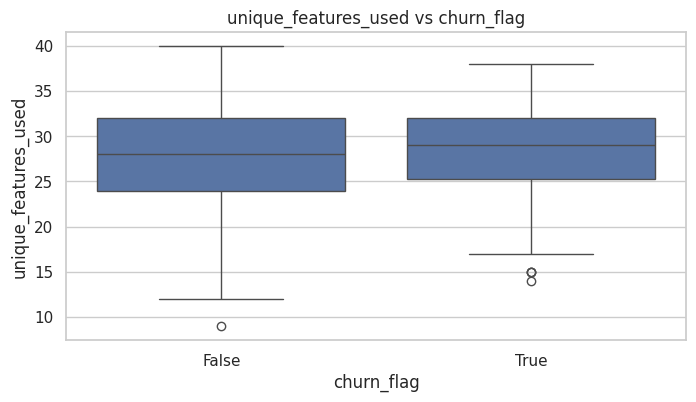

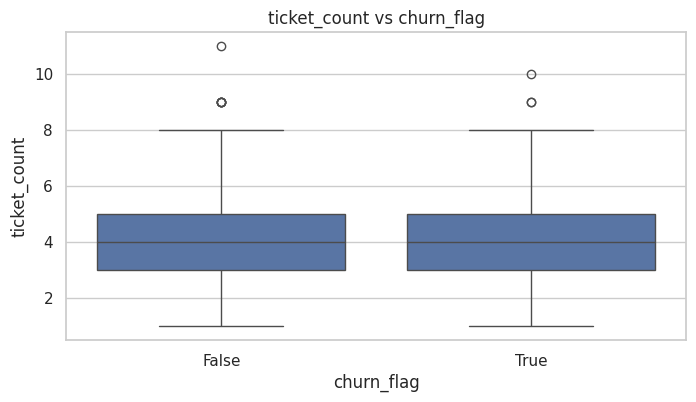

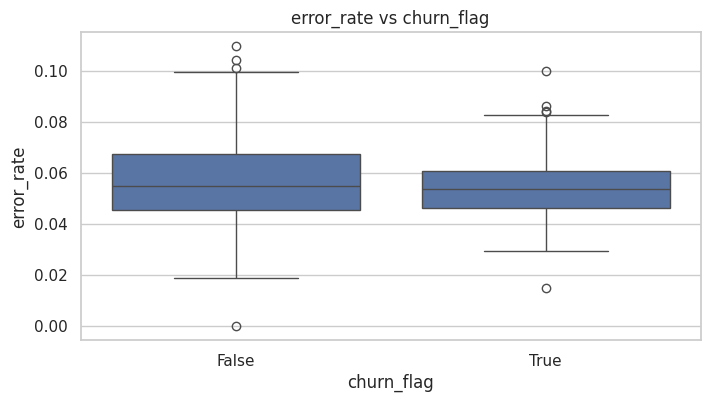

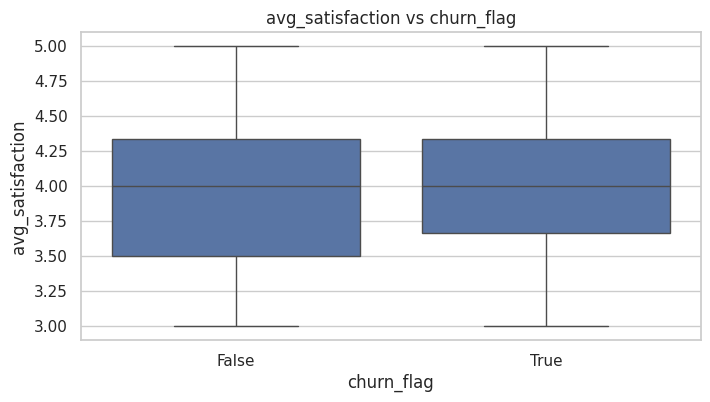

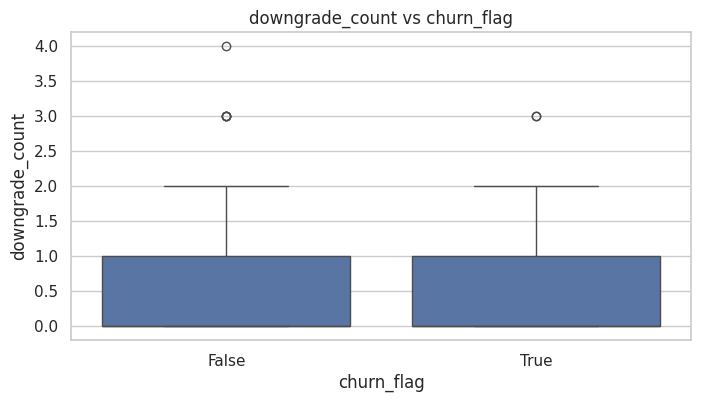

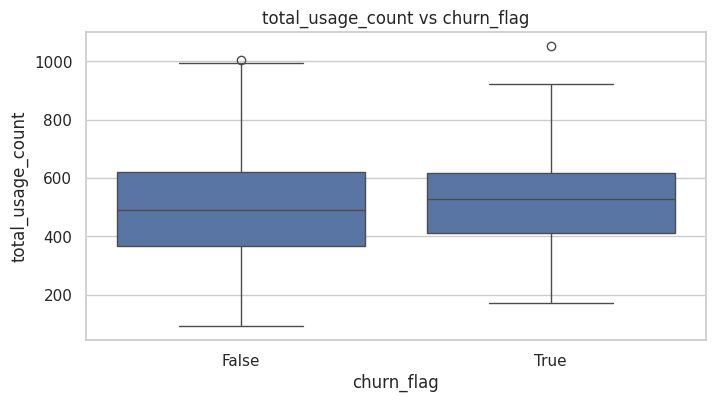

In [17]:
plot_candidates = [
    "unique_features_used",
    "ticket_count",
    "error_rate",
    "avg_satisfaction",
    "downgrade_count",
    "total_usage_count",
]

existing_plot_cols = [c for c in plot_candidates if c in df.columns]

for col in existing_plot_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x="churn_flag", y=col)
    plt.title(f"{col} vs churn_flag")
    plt.show()

### 9.2 Churn por categorias de negócio

In [18]:
cat_cols = [
    "industry",
    "country",
    "referral_source",
    "plan_tier",
    "current_plan_tier",
    "billing_frequency_last",
    "auto_renew_last",
]

for col in [c for c in cat_cols if c in df.columns]:
    tmp = (
        df.groupby(col, dropna=False)["churn_flag"]
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .round(2)
        .to_frame("churn_rate_pct")
        .reset_index()
    )
    print(f"\nChurn rate por {col}:")
    display(tmp.head(20))


Churn rate por industry:


,industry,churn_rate_pct
0,DevTools,30.97
1,FinTech,22.32
2,HealthTech,21.88
3,EdTech,16.46
4,Cybersecurity,16.0



Churn rate por country:


,country,churn_rate_pct
0,DE,32.0
1,US,23.37
2,FR,22.73
3,IN,20.41
4,UK,18.97
5,CA,17.39
6,AU,12.5



Churn rate por referral_source:


...

,current_plan_tier,churn_rate_pct
0,Enterprise,23.3
1,Basic,22.36
2,Pro,20.25



Churn rate por billing_frequency_last:


,billing_frequency_last,churn_rate_pct
0,annual,24.55
1,monthly,18.83



Churn rate por auto_renew_last:


,auto_renew_last,churn_rate_pct
0,True,22.14
1,False,21.35


## 10. Exploração de motivos declarados de churn

Isso não entra no modelo principal, mas ajuda muito na leitura de causa raiz.

In [19]:
if "last_reason_code" in df.columns:
    reason_table = (
        df.loc[df["churn_flag"] == True]
        .groupby("last_reason_code", dropna=False)
        .size()
        .sort_values(ascending=False)
        .to_frame("n_accounts")
        .reset_index()
    )
    print("Motivos declarados entre churnados:")
    display(reason_table)

Motivos declarados entre churnados:


,last_reason_code,n_accounts
0,NaN,35
1,budget,17
2,pricing,16
3,features,15
4,support,14
5,competitor,7
6,unknown,6


## 11. Preparação para modelagem interpretável

### Importante
Para o modelo principal, vamos evitar variáveis claramente pós-evento, como:
- `last_reason_code`
- `refund_amount_total`
- `last_churn_date`
- `churn_event_count`

Também não usamos:
- qualquer coluna `churn_flag` de outras tabelas como feature explicadora
- datas que revelem diretamente encerramento após churn

In [20]:
target = "churn_flag"

candidate_features = [
    # perfil da conta
    "industry", "country", "referral_source", "plan_tier",
    "is_trial", "seats", "account_age_days",

    # assinatura
    "current_plan_tier", "current_seats", "avg_seats",
    "current_mrr", "avg_mrr",
    "billing_frequency_last", "auto_renew_last",
    "upgrade_count", "downgrade_count", "seat_delta_vs_initial",

    # uso
    "total_usage_count", "total_usage_duration", "total_errors",
    "unique_features_used", "usage_days", "error_rate",
    "avg_usage_per_day", "avg_duration_per_event", "beta_usage_events",
    "errors_per_usage_day",

    # suporte
    "ticket_count", "avg_resolution_time", "avg_first_response_min",
    "avg_satisfaction", "escalation_count", "tickets_per_seat", "escalation_rate",
    "priority_low_count", "priority_medium_count", "priority_high_count", "priority_urgent_count",
]

features = [c for c in candidate_features if c in df.columns]

model_df = df[features + [target]].copy()

print("Shape do model_df:", model_df.shape)
display(model_df.head())

Shape do model_df: (500, 39)


,industry,country,referral_source,plan_tier,is_trial,seats,account_age_days,current_plan_tier,current_seats,avg_seats,current_mrr,avg_mrr,billing_frequency_last,auto_renew_last,upgrade_count,downgrade_count,seat_delta_vs_initial,total_usage_count,total_usage_duration,total_errors,unique_features_used,usage_days,error_rate,avg_usage_per_day,avg_duration_per_event,beta_usage_events,errors_per_usage_day,ticket_count,avg_resolution_time,avg_first_response_min,avg_satisfaction,escalation_count,tickets_per_seat,escalation_rate,priority_low_count,priority_medium_count,priority_high_count,priority_urgent_count,churn_flag
0,EdTech,US,partner,Basic,False,9,76,Basic,44,31.200000,836,1260.300000,monthly,True,1,0,35,535,152339,38,27,55,0.071028,9.727273,284.745794,4,0.690909,2.0,23.000000,91.000000,3.000000,0.0,0.045455,0.000000,0.0,0.0,1.0,1.0,False
1,FinTech,IN,other,Basic,False,18,502,Pro,18,22.000000,882,1250.500000,monthly,True,3,0,0,355,101136,14,23,35,0.039437,10.142857,284.890141,2,0.400000,3.0,38.000000,73.333333,4.000000,0.0,0.166667,0.000000,0.0,1.0,0.0,2.0,True
2,DevTools,US,organic,Basic,False,1,126,Pro,2,18.800000,98,1219.066667,annual,True,1,1,1,821,251210,48,34,80,0.058465,10.262500,305.980512,5,0.600000,3.0,43.666667,63.666667,4.666667,0.0,1.500000,0.000000,0.0,2.0,0.0,1.0,False
3,HealthTech,UK,other,Basic,True,24,492,Pro,24,29.857143,1176,1325.000000,monthly,True,2,0,0,382,102528,21,26,40,0.054974,9.550000,268.397906,5,0.525000,2.0,29.000000,174.000000,NaN,0.0,0.083333,0.000000,1.0,0.0,1.0,0.0,False
4,HealthTech,US,event,Enterprise,False,35,65,Enterprise,109,47.111111,21691,5417.888889,monthly,True,2,0,74,579,215779,31,32,56,0.053541,10.339286,372.675302,4,0.553571,7.0,42.285714,107.857143,3.800000,1.0,0.064220,0.142857,0.0,3.0,2.0,2.0,True


## 12. Regressão Logística

A regressão logística é subestimada. Para causa raiz, ela é uma das melhores primeiras opções porque:
- é relativamente interpretável
- fornece direção do efeito
- permite olhar odds ratios

In [21]:
categorical_features = [
    c for c in [
        "industry", "country", "referral_source", "plan_tier",
        "current_plan_tier", "billing_frequency_last"
    ] if c in features
]

boolean_features = [c for c in ["is_trial", "auto_renew_last"] if c in features]

numeric_features = [c for c in features if c not in categorical_features + boolean_features]

X = model_df[features]
y = model_df[target].astype(int)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

bool_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("boo", bool_transformer, boolean_features)
    ]
)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_model.fit(X_train, y_train)

pred_proba = log_model.predict_proba(X_test)[:, 1]
pred = log_model.predict(X_test)

print("ROC-AUC:", round(roc_auc_score(y_test, pred_proba), 4))
print("\nClassification report:")
print(classification_report(y_test, pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, pred))

ROC-AUC: 0.5693

Classification report:
              precision    recall  f1-score   support

           0       0.83      0.58      0.68        78
           1       0.28      0.59      0.38        22

    accuracy                           0.58       100
   macro avg       0.56      0.58      0.53       100
weighted avg       0.71      0.58      0.62       100


Confusion matrix:
[[45 33]
 [ 9 13]]


### 12.1 Interpretação dos coeficientes

- `coef > 0` e `odds_ratio > 1` → variável associada a **maior risco de churn**
- `coef < 0` e `odds_ratio < 1` → variável associada a **menor risco de churn**

Lembrete: isso ainda não é prova causal. É explicação estatística condicional ao modelo.

In [22]:
feature_names = log_model.named_steps["preprocessor"].get_feature_names_out()
coefs = log_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("coef", ascending=False)

print("Top variáveis que aumentam churn:")
display(coef_df.head(25))

print("Top variáveis que reduzem churn:")
display(coef_df.tail(25))

Top variáveis que aumentam churn:


,feature,coef,odds_ratio
37,cat__country_DE,0.601448,1.824760
31,cat__industry_DevTools,0.491961,1.635521
43,cat__referral_source_event,0.475865,1.609406
38,cat__country_FR,0.418189,1.519208
12,num__unique_features_used,0.414511,1.513630
51,cat__current_plan_tier_Enterprise,0.287321,1.332851
11,num__total_errors,0.231144,1.260041
41,cat__country_US,0.224262,1.251399
13,num__usage_days,0.223857,1.250892
25,num__escalation_rate,0.167284,1.182089


Top variáveis que reduzem churn:


,feature,coef,odds_ratio
8,num__seat_delta_vs_initial,-0.069318,0.933030
50,cat__current_plan_tier_Basic,-0.073236,0.929382
48,cat__plan_tier_Enterprise,-0.082661,0.920663
33,cat__industry_FinTech,-0.093724,0.910534
15,num__avg_usage_per_day,-0.120733,0.886271
49,cat__plan_tier_Pro,-0.120884,0.886137
7,num__downgrade_count,-0.129352,0.878665
29,num__priority_urgent_count,-0.136244,0.872630
20,num__avg_resolution_time,-0.136430,0.872468
24,num__tickets_per_seat,-0.140349,0.869055


## 13. Árvore de Decisão rasa

O objetivo aqui não é maximizar performance.  
O objetivo é encontrar **regras explicáveis** do tipo:

> baixo uso + muita escalada + baixa satisfação = alto risco

In [23]:
tree_features = [
    c for c in [
        "current_seats", "avg_seats",
        "current_mrr", "avg_mrr",
        "upgrade_count", "downgrade_count",
        "total_usage_count", "unique_features_used",
        "error_rate", "avg_usage_per_day", "avg_duration_per_event",
        "ticket_count", "avg_resolution_time", "avg_first_response_min",
        "avg_satisfaction", "escalation_count",
        "tickets_per_seat", "escalation_rate",
        "priority_high_count", "priority_urgent_count",
        "account_age_days", "seat_delta_vs_initial"
    ] if c in df.columns
]

tree_df = df[tree_features + [target]].copy()

# Imputação simples para árvore
for c in tree_features:
    tree_df[c] = tree_df[c].fillna(tree_df[c].median())

X_tree = tree_df[tree_features]
y_tree = tree_df[target].astype(int)

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tree, y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=30,
    random_state=42
)

tree_model.fit(X_train_t, y_train_t)

pred_proba_tree = tree_model.predict_proba(X_test_t)[:, 1]

print("ROC-AUC árvore rasa:", round(roc_auc_score(y_test_t, pred_proba_tree), 4))

ROC-AUC árvore rasa: 0.6198


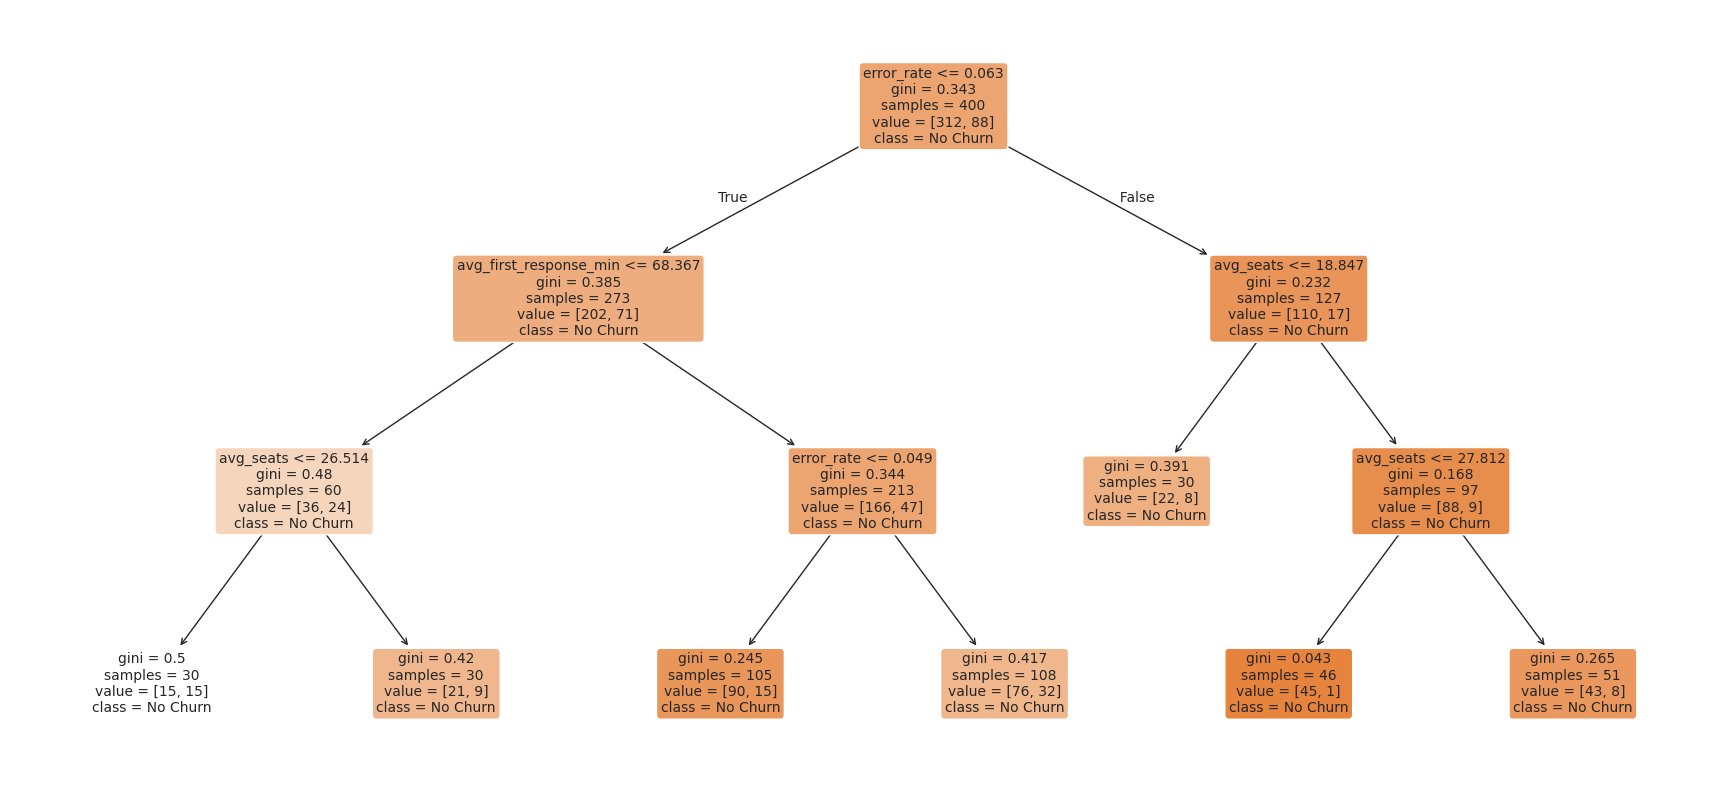

In [24]:
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=tree_features,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

## 14. Random Forest como apoio

Aqui usamos Random Forest apenas para:
- validar se os mesmos drivers aparecem
- capturar relações não lineares
- comparar com a leitura da regressão e da árvore rasa

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced_subsample"
)

rf_model.fit(X_train_t, y_train_t)

pred_proba_rf = rf_model.predict_proba(X_test_t)[:, 1]
print("ROC-AUC random forest:", round(roc_auc_score(y_test_t, pred_proba_rf), 4))

rf_importance = pd.DataFrame({
    "feature": tree_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(rf_importance)

ROC-AUC random forest: 0.6072


,feature,importance
8,error_rate,0.130054
3,avg_mrr,0.099096
13,avg_first_response_min,0.081708
10,avg_duration_per_event,0.076359
12,avg_resolution_time,0.066357
9,avg_usage_per_day,0.061840
6,total_usage_count,0.059817
7,unique_features_used,0.057695
20,account_age_days,0.056505
16,tickets_per_seat,0.045799


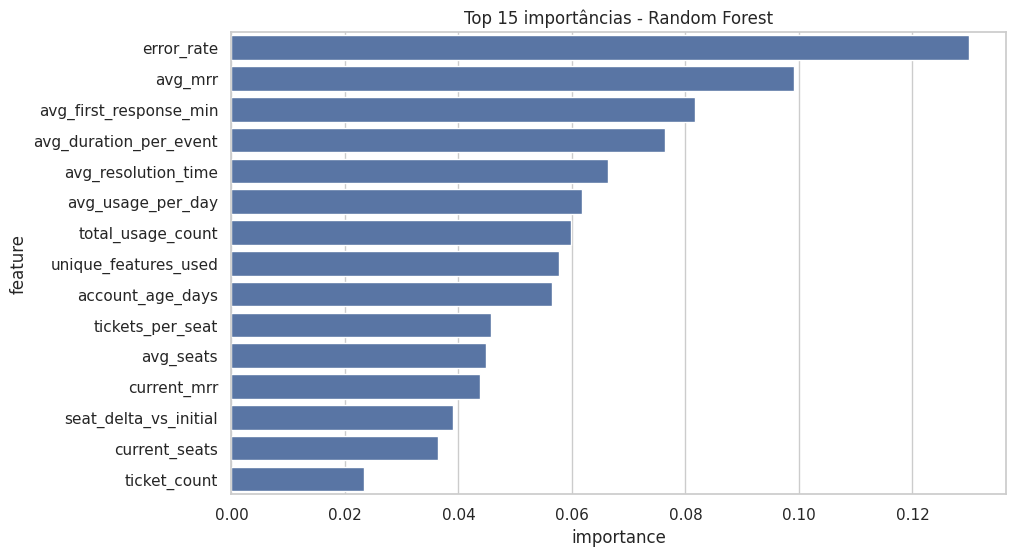

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance.head(15), x="importance", y="feature")
plt.title("Top 15 importâncias - Random Forest")
plt.show()

## 15. Próximos passos recomendados

### Se quiser aprofundar a análise de causa raiz
- criar cohorts por signup month
- analisar churn por fase do ciclo de vida
- comparar curvas de uso antes do churn
- explorar `feedback_text` com NLP leve

### Se quiser evoluir para predição
- trocar a base por snapshots mensais/semanais
- criar label `churn_in_next_30d`
- testar XGBoost / LightGBM
- medir `Precision@K`, `Lift` e `Recall no top decile`

---

Fim.

# Segunda iteração - Verificação do resultado do RandomFlorest (Taxa de Erro como principal fator de Churn).


===== ERROR RATE MÉDIO =====
churn_flag
False    0.057219
True     0.053858
Name: error_rate, dtype: float64


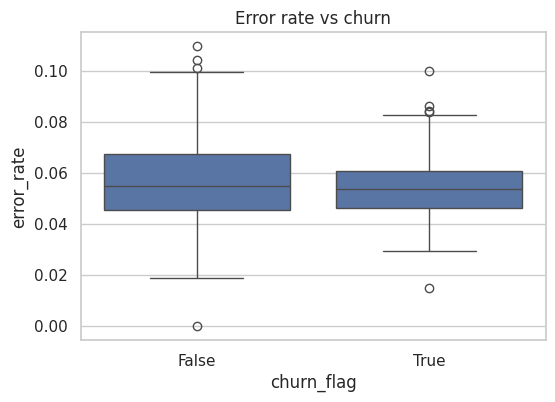


===== CORRELAÇÃO USO vs ERROR RATE =====
                   total_usage_count  error_rate
total_usage_count           1.000000   -0.030779
error_rate                 -0.030779    1.000000


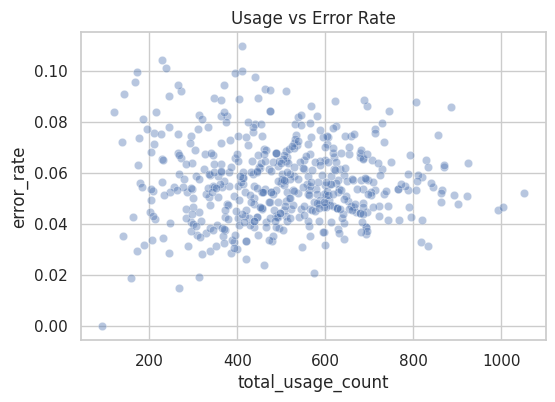

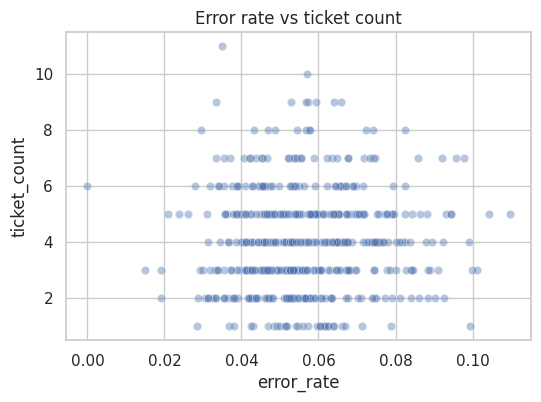

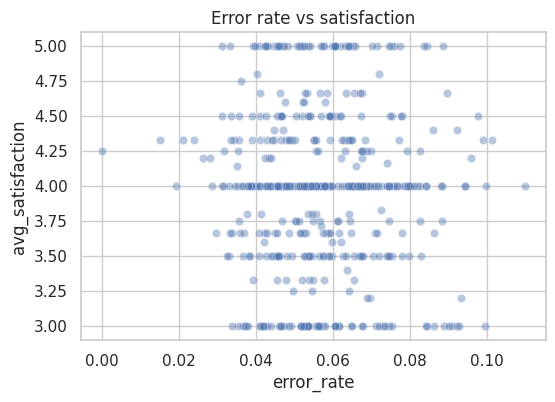


===== CHURN RATE POR ERROR RATE =====
error_bucket
(-0.001, 0.0429]        0.21
(0.0429, 0.0517]        0.23
(0.0517, 0.0588]    0.313725
(0.0588, 0.0683]     0.22449
(0.0683, 0.11]          0.12
Name: churn_flag, dtype: Float64


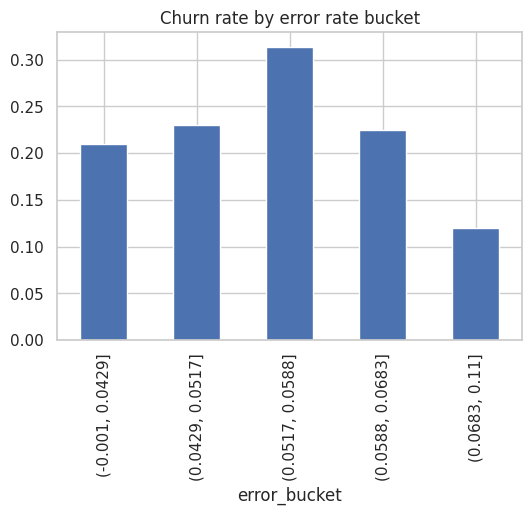


===== EVENT STUDY (90 DIAS ANTES DO CHURN) =====
        avg_usage  avg_errors  avg_duration
window                                     
0-7      9.717105    0.690789   3029.631579
7-30     9.893908    0.528361   2918.084034
30-60   10.032868    0.568611   3097.594906
60-90   10.020194    0.556543   3068.550889


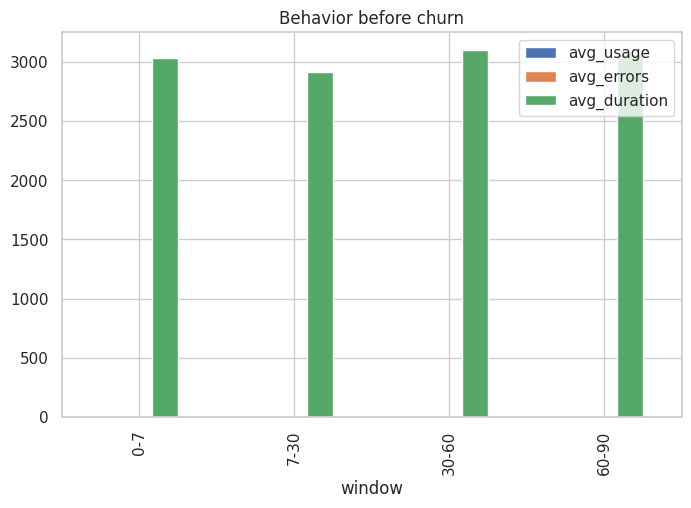


===== CHURN RATE POR INDUSTRY =====
               churn_rate  accounts
industry                           
DevTools         0.309735       113
FinTech          0.223214       112
HealthTech        0.21875        96
EdTech           0.164557        79
Cybersecurity        0.16       100


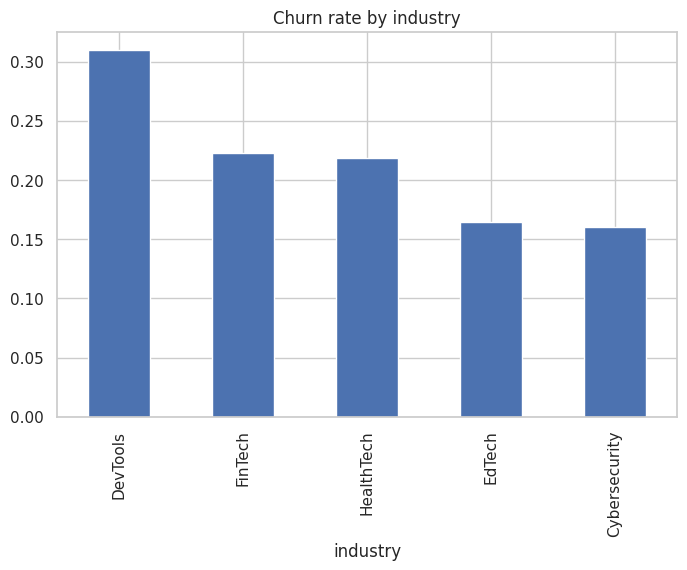


===== ERROR RATE POR INDUSTRY =====
               avg_error_rate  churn_rate
industry                                 
Cybersecurity        0.055833        0.16
DevTools             0.056320    0.309735
EdTech               0.056635    0.164557
FinTech              0.054830    0.223214
HealthTech           0.059138     0.21875

===== FEATURES COM MAIOR ERROR RATE =====
              total_usage  total_errors  error_rate
feature_name                                       
feature_4            6374           418    0.065579
feature_9            6207           404    0.065088
feature_26           6470           417    0.064451
feature_16           6273           396    0.063128
feature_18           5850           369    0.063077
feature_2            6525           401    0.061456
feature_40           6222           380    0.061074
feature_13           6099           372    0.060994
feature_34           6536           397    0.060741
feature_19           5900           352    0.059661
fe

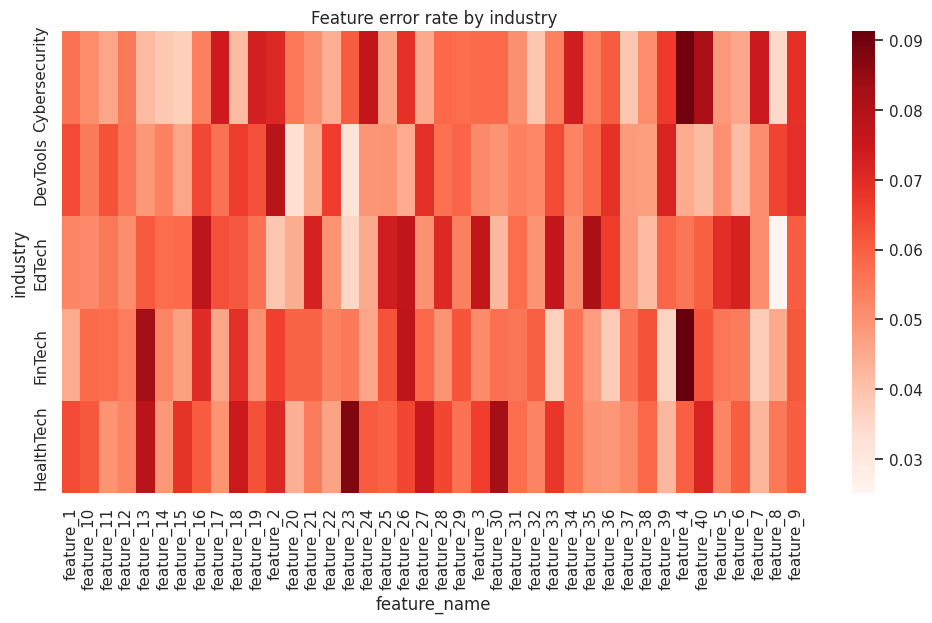

In [27]:
# ============================================================
# ROOT CAUSE ANALYSIS — CHURN
# ============================================================

# O modelo indicou que error_rate é o principal fator associado ao churn.
# Agora vamos validar essa hipótese e explorar:
# 1) Se erro realmente diferencia churn vs non-churn
# 2) Se erro é apenas consequência de uso alto
# 3) Se erro está ligado a suporte / satisfação
# 4) Comportamento antes do churn (event study)
# 5) Segmentos com maior churn
# 6) Features com maior taxa de erro
# 7) Bugs por segmento

import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# HIPÓTESE 1
# MAIS ERROS → MAIS CHURN
# ============================================================

print("\n===== ERROR RATE MÉDIO =====")

print(
    df.groupby("churn_flag")["error_rate"]
    .mean()
)

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="churn_flag", y="error_rate")
plt.title("Error rate vs churn")
plt.show()


# ============================================================
# HIPÓTESE 2
# ERRO PODE SER CONSEQUÊNCIA DE USO ALTO
# ============================================================

print("\n===== CORRELAÇÃO USO vs ERROR RATE =====")

print(
    df[["total_usage_count","error_rate"]]
    .corr()
)

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="total_usage_count",
    y="error_rate",
    alpha=0.4
)
plt.title("Usage vs Error Rate")
plt.show()


# ============================================================
# HIPÓTESE 3
# ERROS PODEM GERAR TICKETS E BAIXA SATISFAÇÃO
# ============================================================

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="error_rate",
    y="ticket_count",
    alpha=0.4
)
plt.title("Error rate vs ticket count")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="error_rate",
    y="avg_satisfaction",
    alpha=0.4
)
plt.title("Error rate vs satisfaction")
plt.show()


# ============================================================
# CURVA DE CHURN POR FAIXA DE ERRO
# ============================================================

df["error_bucket"] = pd.qcut(df["error_rate"], 5)

error_churn_curve = (
    df.groupby("error_bucket")["churn_flag"]
    .mean()
)

print("\n===== CHURN RATE POR ERROR RATE =====")

print(error_churn_curve)

error_churn_curve.plot(kind="bar", figsize=(6,4))
plt.title("Churn rate by error rate bucket")
plt.show()


# ============================================================
# EVENT STUDY — COMPORTAMENTO ANTES DO CHURN
# ============================================================

print("\n===== EVENT STUDY (90 DIAS ANTES DO CHURN) =====")

usage = feature_usage.merge(
    subscriptions[["subscription_id","account_id"]],
    on="subscription_id",
    how="left"
)

usage = usage.merge(
    churn_events[["account_id","churn_date"]],
    on="account_id",
    how="left"
)

usage["days_to_churn"] = (
    usage["churn_date"] - usage["usage_date"]
).dt.days

usage_pre = usage[
    (usage["days_to_churn"] >= 0) &
    (usage["days_to_churn"] <= 90)
]

usage_pre["window"] = pd.cut(
    usage_pre["days_to_churn"],
    bins=[0,7,30,60,90],
    labels=["0-7","7-30","30-60","60-90"]
)

event_study = usage_pre.groupby("window").agg(
    avg_usage=("usage_count","mean"),
    avg_errors=("error_count","mean"),
    avg_duration=("usage_duration_secs","mean")
)

print(event_study)

event_study.plot(kind="bar", figsize=(8,5))
plt.title("Behavior before churn")
plt.show()


# ============================================================
# SEGMENTOS COM MAIOR CHURN
# ============================================================

print("\n===== CHURN RATE POR INDUSTRY =====")

industry_churn = df.groupby("industry").agg(
    churn_rate=("churn_flag","mean"),
    accounts=("account_id","count")
).sort_values("churn_rate", ascending=False)

print(industry_churn)

industry_churn["churn_rate"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn rate by industry")
plt.show()


# ============================================================
# ERROR RATE POR SEGMENTO
# ============================================================

print("\n===== ERROR RATE POR INDUSTRY =====")

segment_error = df.groupby("industry").agg(
    avg_error_rate=("error_rate","mean"),
    churn_rate=("churn_flag","mean")
)

print(segment_error)


# ============================================================
# FEATURES COM MAIS ERROS
# ============================================================

print("\n===== FEATURES COM MAIOR ERROR RATE =====")

feature_analysis = feature_usage.groupby("feature_name").agg(
    total_usage=("usage_count","sum"),
    total_errors=("error_count","sum")
)

feature_analysis["error_rate"] = (
    feature_analysis["total_errors"] /
    feature_analysis["total_usage"]
)

feature_analysis = feature_analysis.sort_values(
    "error_rate",
    ascending=False
)

print(feature_analysis.head(20))


# ============================================================
# FEATURES PROBLEMÁTICAS POR SEGMENTO
# ============================================================

print("\n===== ERROR RATE POR FEATURE E INDUSTRY =====")

usage_seg = usage.merge(
    accounts[["account_id","industry"]],
    on="account_id"
)

feature_segment = usage_seg.groupby(
    ["industry","feature_name"]
).agg(
    usage=("usage_count","sum"),
    errors=("error_count","sum")
)

feature_segment["error_rate"] = (
    feature_segment["errors"] /
    feature_segment["usage"]
)

feature_segment = feature_segment.sort_values(
    "error_rate",
    ascending=False
)

print(feature_segment.head(20))


# ============================================================
# HEATMAP DE BUGS POR SEGMENTO
# ============================================================

pivot = feature_segment.reset_index().pivot_table(
    index="industry",
    columns="feature_name",
    values="error_rate"
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap="Reds"
)

plt.title("Feature error rate by industry")

plt.show()

# Terceira Iteração - Análise de Heavy-Users

In [28]:
df.groupby("churn_flag")[[
    "unique_features_used",
    "total_usage_count",
    "usage_days"
]].mean()

,unique_features_used,total_usage_count,usage_days
churn_flag,,,
False,27.412821,495.130769,47.689744
True,28.336364,522.036364,50.109091


In [29]:
df.groupby("industry")[[
    "unique_features_used",
    "total_usage_count"
]].mean()

,unique_features_used,total_usage_count
industry,,
Cybersecurity,27.640000,503.720000
DevTools,27.469027,507.893805
EdTech,27.658228,506.392405
FinTech,27.785714,499.357143
HealthTech,27.531250,487.791667


In [30]:
df.groupby("current_plan_tier")["churn_flag"].mean()

,churn_flag
current_plan_tier,
Basic,0.223602
Enterprise,0.232955
Pro,0.202454


In [31]:
df.groupby(pd.qcut(df["current_seats"],5))["churn_flag"].mean()

,churn_flag
current_seats,
"(0.999, 13.0]",0.247525
"(13.0, 20.0]",0.25
"(20.0, 30.0]",0.207547
"(30.0, 44.0]",0.185567
"(44.0, 170.0]",0.208333


In [32]:
df["usage_bucket"] = pd.qcut(df["total_usage_count"],5)

df.groupby("usage_bucket")["churn_flag"].mean()

,churn_flag
usage_bucket,
"(91.999, 347.0]",0.156863
"(347.0, 452.2]",0.244898
"(452.2, 545.8]",0.2
"(545.8, 644.0]",0.267327
"(644.0, 1053.0]",0.232323


In [33]:
usage_churn = usage_seg.merge(
    accounts[["account_id","churn_flag"]],
    on="account_id"
)

feature_churn = usage_churn.groupby(
    ["feature_name","churn_flag"]
)["usage_count"].sum().unstack()

feature_churn["churn_ratio"] = (
    feature_churn[True] /
    (feature_churn[True] + feature_churn[False])
)

feature_churn.sort_values("churn_ratio", ascending=False)

churn_flag,False,True,churn_ratio
feature_name,,,
feature_11,6990,2597,0.270888
feature_4,7154,2447,0.254869
feature_37,7005,2355,0.251603
feature_20,7125,2375,0.250000
feature_38,7260,2414,0.249535
feature_26,7336,2431,0.248899
feature_34,7377,2428,0.247629
feature_1,7081,2324,0.247103
feature_19,6614,2131,0.243682


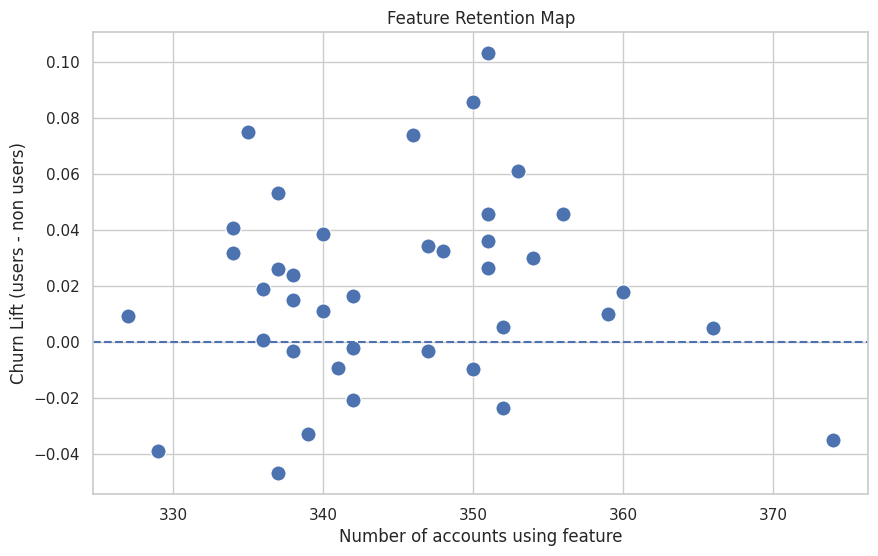


===== TOP RETENTION DRIVERS =====
       feature  users churn_users churn_non_users churn_lift
8   feature_16    337    0.204748        0.251534  -0.046786
16  feature_23    329    0.206687        0.245614  -0.038927
4   feature_12    374     0.21123        0.246032  -0.034802
25  feature_31    339     0.20944        0.242236  -0.032796
6   feature_14    352    0.213068        0.236486  -0.023418
37   feature_6    342     0.21345        0.234177  -0.020727
28  feature_34    350    0.217143        0.226667  -0.009524
24  feature_30    341    0.217009        0.226415  -0.009406
20  feature_27    338    0.218935        0.222222  -0.003287
21  feature_28    347     0.21902        0.222222  -0.003202

===== FEATURES ASSOCIADAS AO CHURN =====
       feature  users churn_users churn_non_users churn_lift
31  feature_37    351    0.250712        0.147651   0.103061
5   feature_13    350    0.245714            0.16   0.085714
11  feature_19    335    0.244776        0.169697   0.075079
34   fea

In [34]:
# ============================================================
# FEATURE RETENTION MAP
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) PREPARAR BASE DE USO
# ------------------------------------------------------------

usage_features = feature_usage.merge(
    subscriptions[["subscription_id","account_id"]],
    on="subscription_id",
    how="left"
)

usage_features = usage_features.merge(
    accounts[["account_id","churn_flag"]],
    on="account_id"
)

# ------------------------------------------------------------
# 2) MATRIZ ACCOUNT x FEATURE
# ------------------------------------------------------------

feature_matrix = (
    usage_features
    .groupby(["account_id","feature_name"])["usage_count"]
    .sum()
    .unstack()
    .fillna(0)
)

# converter para presença de uso
feature_matrix = (feature_matrix > 0).astype(int)

# adicionar churn
feature_matrix = feature_matrix.merge(
    accounts[["account_id","churn_flag"]],
    on="account_id"
)

# ------------------------------------------------------------
# 3) CALCULAR CHURN POR FEATURE
# ------------------------------------------------------------

feature_results = []

for feature in feature_matrix.columns[:-1]:

    users = feature_matrix[feature_matrix[feature] == 1]
    non_users = feature_matrix[feature_matrix[feature] == 0]

    churn_users = users["churn_flag"].mean()
    churn_non_users = non_users["churn_flag"].mean()

    churn_lift = churn_users - churn_non_users

    feature_results.append({
        "feature": feature,
        "users": len(users),
        "churn_users": churn_users,
        "churn_non_users": churn_non_users,
        "churn_lift": churn_lift
    })

feature_retention = pd.DataFrame(feature_results)

# ordenar
feature_retention = feature_retention.sort_values(
    "churn_lift",
    ascending=False
)

# ------------------------------------------------------------
# 4) FEATURE RETENTION MAP
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=feature_retention,
    x="users",
    y="churn_lift",
    s=120
)

plt.axhline(0, linestyle="--")

plt.xlabel("Number of accounts using feature")
plt.ylabel("Churn Lift (users - non users)")
plt.title("Feature Retention Map")

plt.show()


# ------------------------------------------------------------
# 5) IDENTIFICAR RETENTION DRIVERS
# ------------------------------------------------------------

print("\n===== TOP RETENTION DRIVERS =====")

retention_drivers = feature_retention.sort_values("churn_lift")

print(
    retention_drivers.head(10)
)


# ------------------------------------------------------------
# 6) IDENTIFICAR CHURN SIGNALS
# ------------------------------------------------------------

print("\n===== FEATURES ASSOCIADAS AO CHURN =====")

churn_features = feature_retention.sort_values(
    "churn_lift",
    ascending=False
)

print(
    churn_features.head(10)
)


# ------------------------------------------------------------
# 7) FEATURES MAIS POPULARES
# ------------------------------------------------------------

print("\n===== FEATURES MAIS UTILIZADAS =====")

popular_features = feature_retention.sort_values(
    "users",
    ascending=False
)

print(
    popular_features.head(10)
)


# ------------------------------------------------------------
# 8) CLASSIFICAÇÃO DAS FEATURES
# ------------------------------------------------------------

feature_retention["category"] = "neutral"

feature_retention.loc[
    feature_retention["churn_lift"] < -0.02,
    "category"
] = "retention_driver"

feature_retention.loc[
    feature_retention["churn_lift"] > 0.02,
    "category"
] = "churn_signal"

print("\n===== CLASSIFICAÇÃO FINAL =====")

print(
    feature_retention.sort_values(
        "churn_lift"
    ).head(20)
)

In [39]:
# ============================================================
# CHURN FEATURES ANALYSIS
# heavy users + churn dentro de cada segmento
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1) DEFINIR CHURN FEATURES (do retention map)
# ------------------------------------------------------------

churn_features = [
    "feature_37",
    "feature_13",
    "feature_19",
    "feature_4",
    "feature_38",
    "feature_10",
    "feature_15",
    "feature_39",
    "feature_22",
    "feature_1"
]


# ------------------------------------------------------------
# 2) MATRIZ ACCOUNT x FEATURE
# ------------------------------------------------------------

usage_features = feature_usage.merge(
    subscriptions[["subscription_id","account_id"]],
    on="subscription_id",
    how="left"
)

feature_matrix = (
    usage_features
    .groupby(["account_id","feature_name"])["usage_count"]
    .sum()
    .unstack()
    .fillna(0)
)

feature_matrix = (feature_matrix > 0).astype(int)

# adicionar dados da conta
feature_matrix = feature_matrix.merge(
    accounts[["account_id","industry","churn_flag"]],
    on="account_id"
)

# adicionar métricas de uso
usage_per_account = usage_features.groupby("account_id")["usage_count"].sum()

feature_matrix = feature_matrix.merge(
    usage_per_account.rename("total_usage_count"),
    on="account_id"
)


# ------------------------------------------------------------
# 3) CHURN FEATURES × HEAVY USERS
# ------------------------------------------------------------

heavy_user_results = []

for feature in churn_features:

    users = feature_matrix[feature_matrix[feature] == 1]
    non_users = feature_matrix[feature_matrix[feature] == 0]

    avg_usage_users = users["total_usage_count"].mean()
    avg_usage_non_users = non_users["total_usage_count"].mean()

    heavy_user_results.append({
        "feature": feature,
        "avg_usage_users": avg_usage_users,
        "avg_usage_non_users": avg_usage_non_users,
        "usage_difference": avg_usage_users - avg_usage_non_users
    })

heavy_user_df = pd.DataFrame(heavy_user_results)

print("\n===== CHURN FEATURES × HEAVY USERS =====")
print(
    heavy_user_df.sort_values(
        "usage_difference",
        ascending=False
    )
)


# ------------------------------------------------------------
# 4) CHURN DA FEATURE DENTRO DO SEGMENTO
# ------------------------------------------------------------

segment_results = []

for feature in churn_features:

    for segment in feature_matrix["industry"].unique():

        segment_data = feature_matrix[
            feature_matrix["industry"] == segment
        ]

        users = segment_data[segment_data[feature] == 1]

        if len(users) > 10:

            churn_rate = users["churn_flag"].mean()

            segment_results.append({
                "feature": feature,
                "industry": segment,
                "accounts_using_feature": len(users),
                "churn_rate": churn_rate
            })

segment_churn_df = pd.DataFrame(segment_results)

print("\n===== CHURN RATE POR FEATURE E SEGMENTO =====")

print(
    segment_churn_df.sort_values(
        "churn_rate",
        ascending=False
    ).head(30)
)


# ------------------------------------------------------------
# 5) PIVOT PARA VISUALIZAÇÃO
# ------------------------------------------------------------

pivot_segment = segment_churn_df.pivot(
    index="feature",
    columns="industry",
    values="churn_rate"
)

print("\n===== PIVOT CHURN FEATURE × INDUSTRY =====")

print(pivot_segment)


===== CHURN FEATURES × HEAVY USERS =====
      feature  avg_usage_users  avg_usage_non_users  usage_difference
0  feature_37       537.245014           415.785235        121.459779
6  feature_15       536.068376           418.557047        117.511329
5  feature_10       538.341246           423.950920        114.390326
9   feature_1       535.014706           428.875000        106.139706
8  feature_22       535.961078           430.807229        105.153849
3   feature_4       533.147399           428.935065        104.212334
1  feature_13       530.028571           433.433333         96.595238
7  feature_39       528.070225           434.250000         93.820225
4  feature_38       526.065156           440.979592         85.085564
2  feature_19       526.486567           449.406061         77.080507

===== CHURN RATE POR FEATURE E SEGMENTO =====
       feature    industry  accounts_using_feature  churn_rate
44  feature_22    DevTools                      72    0.375000
4   feature_37 

# Quarta iteração - Mapa de Valor de Feature por Segmento


===== BASELINE CHURN POR SEGMENTO =====
industry
Cybersecurity        0.16
DevTools         0.309735
EdTech           0.164557
FinTech          0.223214
HealthTech        0.21875
Name: churn_flag, dtype: Float64

===== SEGMENT × FEATURE VALUE MAP =====
feature        feature_1  feature_10  feature_11  feature_12  feature_13  feature_14  feature_15  feature_16  feature_17  feature_18  feature_19  feature_2  feature_20  feature_21  feature_22  \
industry                                                                                                                                                                                          
Cybersecurity   0.034030    0.019104   -0.007222   -0.004156    0.009231    0.006667    0.037183    0.014603    0.006667   -0.028852    0.025714   0.034805   -0.038788    0.048333    0.011429   
DevTools       -0.040504   -0.018595    0.023599    0.023599    0.023599    0.011253   -0.016401   -0.062981   -0.006364   -0.005937    0.007913  -0.011033    0.

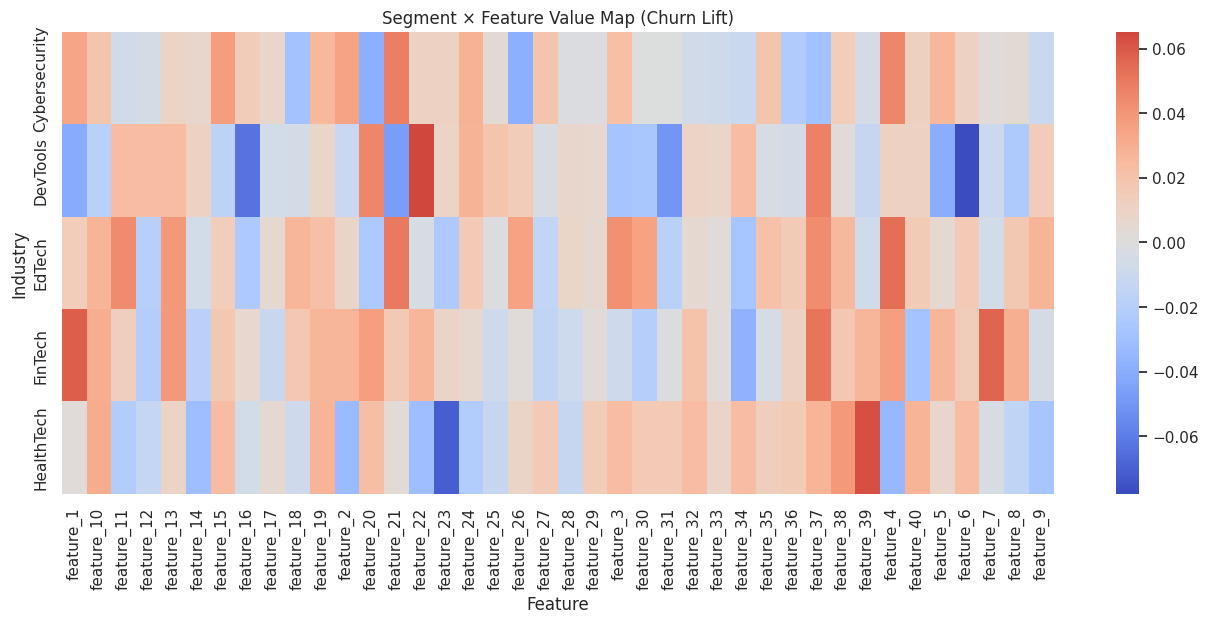


===== TOP RETENTION FEATURES POR SEGMENTO =====

Cybersecurity
feature
feature_20   -0.038788
feature_26   -0.038378
feature_37   -0.029565
feature_18   -0.028852
feature_36   -0.023014
Name: Cybersecurity, dtype: float64

DevTools
feature
feature_6    -0.077850
feature_16   -0.062981
feature_31   -0.049994
feature_21   -0.046577
feature_1    -0.040504
Name: DevTools, dtype: float64

EdTech
feature
feature_34   -0.027302
feature_16   -0.024206
feature_20   -0.024206
feature_23   -0.024206
feature_12   -0.019396
Name: EdTech, dtype: float64

FinTech
feature
feature_34   -0.038029
feature_40   -0.028409
feature_12   -0.020833
feature_30   -0.020683
feature_14   -0.018086
Name: FinTech, dtype: float64

HealthTech
feature
feature_23   -0.071209
feature_4    -0.034135
feature_2    -0.033036
feature_14   -0.031250
feature_22   -0.031250
Name: HealthTech, dtype: float64

===== TOP CHURN FEATURES POR SEGMENTO =====

Cybersecurity
feature
feature_21    0.048333
feature_4     0.045882
feature_1

In [40]:
# ============================================================
# SEGMENT × FEATURE VALUE MAP
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) PREPARAR BASE
# ------------------------------------------------------------

usage_seg = feature_usage.merge(
    subscriptions[["subscription_id","account_id"]],
    on="subscription_id",
    how="left"
)

usage_seg = usage_seg.merge(
    accounts[["account_id","industry","churn_flag"]],
    on="account_id"
)

# ------------------------------------------------------------
# 2) MATRIZ ACCOUNT x FEATURE
# ------------------------------------------------------------

feature_matrix = (
    usage_seg
    .groupby(["account_id","feature_name"])["usage_count"]
    .sum()
    .unstack()
    .fillna(0)
)

feature_matrix = (feature_matrix > 0).astype(int)

feature_matrix = feature_matrix.merge(
    accounts[["account_id","industry","churn_flag"]],
    on="account_id"
)

# ------------------------------------------------------------
# 3) BASELINE CHURN POR SEGMENTO
# ------------------------------------------------------------

baseline_churn = feature_matrix.groupby("industry")["churn_flag"].mean()

print("\n===== BASELINE CHURN POR SEGMENTO =====")
print(baseline_churn)


# ------------------------------------------------------------
# 4) CALCULAR FEATURE VALUE LIFT
# ------------------------------------------------------------

results = []

features = feature_matrix.columns[:-2]

for feature in features:

    for segment in feature_matrix["industry"].unique():

        segment_data = feature_matrix[
            feature_matrix["industry"] == segment
        ]

        users = segment_data[segment_data[feature] == 1]

        if len(users) > 10:

            churn_users = users["churn_flag"].mean()

            baseline = baseline_churn.loc[segment]

            value_lift = churn_users - baseline

            results.append({
                "industry": segment,
                "feature": feature,
                "accounts": len(users),
                "churn_users": churn_users,
                "baseline_churn": baseline,
                "value_lift": value_lift
            })

segment_feature_value = pd.DataFrame(results)

# ------------------------------------------------------------
# 5) PIVOT PARA MAPA
# ------------------------------------------------------------

value_map = segment_feature_value.pivot(
    index="industry",
    columns="feature",
    values="value_lift"
)

print("\n===== SEGMENT × FEATURE VALUE MAP =====")
print(value_map)


# ------------------------------------------------------------
# 6) HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(16,6))

sns.heatmap(
    value_map,
    cmap="coolwarm",
    center=0
)

plt.title("Segment × Feature Value Map (Churn Lift)")
plt.xlabel("Feature")
plt.ylabel("Industry")

plt.show()


# ------------------------------------------------------------
# 7) FEATURES QUE REDUZEM CHURN POR SEGMENTO
# ------------------------------------------------------------

print("\n===== TOP RETENTION FEATURES POR SEGMENTO =====")

for segment in value_map.index:

    best = value_map.loc[segment].sort_values().head(5)

    print(f"\n{segment}")
    print(best)


# ------------------------------------------------------------
# 8) FEATURES ASSOCIADAS AO CHURN POR SEGMENTO
# ------------------------------------------------------------

print("\n===== TOP CHURN FEATURES POR SEGMENTO =====")

for segment in value_map.index:

    worst = value_map.loc[segment].sort_values(
        ascending=False
    ).head(5)

    print(f"\n{segment}")
    print(worst)

Quinta Iteração



===== AHA MOMENT ANALYSIS =====
                         churn_rate  accounts
retention_features_used                      
0                          0.333333         3
1                          0.210526        19
2                          0.222222        45
3                          0.285714        77
4                           0.24031       129
5                          0.213793       145
6                          0.134146        82


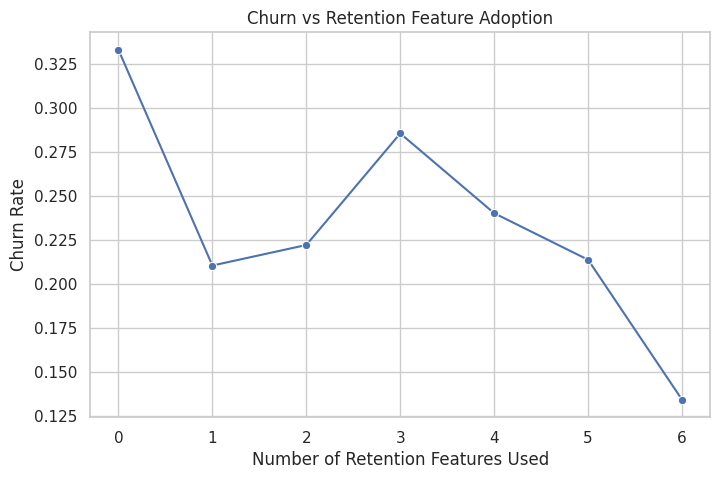


===== REDUÇÃO DE CHURN =====
                         churn_rate  accounts  churn_reduction
retention_features_used                                       
0                          0.333333         3        -0.113333
1                          0.210526        19         0.009474
2                          0.222222        45        -0.002222
3                          0.285714        77        -0.065714
4                           0.24031       129         -0.02031
5                          0.213793       145         0.006207
6                          0.134146        82         0.085854

===== ACTIVATION FUNNEL =====
         stage  accounts  percentage
0  0+ features       500       1.000
1  1+ features       497       0.994
2  2+ features       478       0.956
3  3+ features       433       0.866
4  4+ features       356       0.712
5  5+ features       227       0.454
6  6+ features        82       0.164


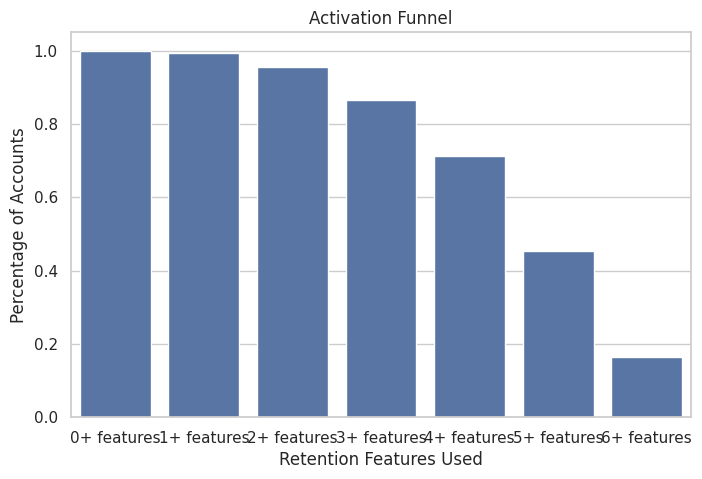


===== ACTIVATION FUNNEL POR SEGMENTO =====
         industry  retention_features_used  account_id
0   Cybersecurity                        1           8
1   Cybersecurity                        2           3
2   Cybersecurity                        3          16
3   Cybersecurity                        4          22
4   Cybersecurity                        5          35
5   Cybersecurity                        6          16
6        DevTools                        0           1
7        DevTools                        1           5
8        DevTools                        2          14
9        DevTools                        3          17
10       DevTools                        4          27
11       DevTools                        5          32
12       DevTools                        6          17
13         EdTech                        0           1
14         EdTech                        1           2
15         EdTech                        2           6
16         EdTech    

In [41]:
# ============================================================
# AHA MOMENT + ACTIVATION FUNNEL ANALYSIS
# ============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) DEFINIR RETENTION FEATURES
# ------------------------------------------------------------

retention_features = [
    "feature_16",
    "feature_23",
    "feature_12",
    "feature_31",
    "feature_14",
    "feature_6"
]

# ------------------------------------------------------------
# 2) MATRIZ ACCOUNT x FEATURE
# ------------------------------------------------------------

usage_features = feature_usage.merge(
    subscriptions[["subscription_id","account_id"]],
    on="subscription_id",
    how="left"
)

feature_matrix = (
    usage_features
    .groupby(["account_id","feature_name"])["usage_count"]
    .sum()
    .unstack()
    .fillna(0)
)

feature_matrix = (feature_matrix > 0).astype(int)

feature_matrix = feature_matrix.merge(
    accounts[["account_id","churn_flag","industry"]],
    on="account_id"
)

# ------------------------------------------------------------
# 3) CONTAR QUANTAS RETENTION FEATURES CADA CONTA USA
# ------------------------------------------------------------

feature_matrix["retention_features_used"] = feature_matrix[
    retention_features
].sum(axis=1)

# ------------------------------------------------------------
# 4) AHA MOMENT ANALYSIS
# ------------------------------------------------------------

aha_analysis = feature_matrix.groupby(
    "retention_features_used"
)["churn_flag"].agg(["mean","count"])

aha_analysis = aha_analysis.rename(
    columns={
        "mean":"churn_rate",
        "count":"accounts"
    }
)

print("\n===== AHA MOMENT ANALYSIS =====")
print(aha_analysis)


# ------------------------------------------------------------
# 5) VISUALIZAR AHA MOMENT
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.lineplot(
    data=aha_analysis.reset_index(),
    x="retention_features_used",
    y="churn_rate",
    marker="o"
)

plt.title("Churn vs Retention Feature Adoption")
plt.xlabel("Number of Retention Features Used")
plt.ylabel("Churn Rate")

plt.show()


# ------------------------------------------------------------
# 6) DEFINIR AHA MOMENT
# ------------------------------------------------------------

baseline_churn = feature_matrix["churn_flag"].mean()

aha_analysis["churn_reduction"] = (
    baseline_churn - aha_analysis["churn_rate"]
)

print("\n===== REDUÇÃO DE CHURN =====")
print(aha_analysis)


# ------------------------------------------------------------
# 7) ACTIVATION FUNNEL
# ------------------------------------------------------------

total_accounts = len(feature_matrix)

funnel = []

for n in range(len(retention_features)+1):

    accounts_stage = feature_matrix[
        feature_matrix["retention_features_used"] >= n
    ]

    funnel.append({
        "stage": f"{n}+ features",
        "accounts": len(accounts_stage),
        "percentage": len(accounts_stage)/total_accounts
    })

funnel_df = pd.DataFrame(funnel)

print("\n===== ACTIVATION FUNNEL =====")
print(funnel_df)


# ------------------------------------------------------------
# 8) VISUALIZAR FUNIL
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

sns.barplot(
    data=funnel_df,
    x="stage",
    y="percentage"
)

plt.title("Activation Funnel")
plt.ylabel("Percentage of Accounts")
plt.xlabel("Retention Features Used")

plt.show()


# ------------------------------------------------------------
# 9) FUNIL POR SEGMENTO
# ------------------------------------------------------------

segment_funnel = feature_matrix.groupby(
    ["industry","retention_features_used"]
)["account_id"].count().reset_index()

print("\n===== ACTIVATION FUNNEL POR SEGMENTO =====")
print(segment_funnel)

# Quinta Iteração - Engine de Retenção

In [43]:
# ============================================================
# RETENTION FEATURE RECOMMENDATION ENGINE
# cliente -> quais features sugerir
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1) RETENTION FEATURES (identificadas na análise)
# ------------------------------------------------------------

retention_features = [
    "feature_16",
    "feature_23",
    "feature_12",
    "feature_31",
    "feature_14",
    "feature_6"
]

# ------------------------------------------------------------
# 2) MATRIZ ACCOUNT x FEATURE
# ------------------------------------------------------------

usage_features = feature_usage.merge(
    subscriptions[["subscription_id","account_id"]],
    on="subscription_id",
    how="left"
)

feature_matrix = (
    usage_features
    .groupby(["account_id","feature_name"])["usage_count"]
    .sum()
    .unstack()
    .fillna(0)
)

feature_matrix = (feature_matrix > 0).astype(int)

feature_matrix = feature_matrix.merge(
    accounts[["account_id","account_name","industry","churn_flag"]],
    on="account_id"
)

# ------------------------------------------------------------
# 3) SEGMENT × FEATURE VALUE
# (calculado anteriormente no value map)
# ------------------------------------------------------------

value_lookup = segment_feature_value.set_index(
    ["industry","feature"]
)["value_lift"].to_dict()

# ------------------------------------------------------------
# 4) GERAR RECOMENDAÇÕES POR CLIENTE
# ------------------------------------------------------------

recommendations = []

for _, row in feature_matrix.iterrows():

    account = row["account_name"]
    account_id = row["account_id"]
    industry = row["industry"]

    suggested_features = []

    for feature in retention_features:

        if row[feature] == 0:

            value = value_lookup.get((industry, feature), None)

            if value is not None and value < 0:

                suggested_features.append((feature, value))

    suggested_features = sorted(
        suggested_features,
        key=lambda x: x[1]
    )

    top_features = [f[0] for f in suggested_features[:3]]

    recommendations.append({
        "account_id": account_id,
        "account_name": account,
        "industry": industry,
        "recommended_features": top_features
    })

recommendation_df = pd.DataFrame(recommendations)

print("\n===== FEATURE RECOMMENDATIONS =====")

print(recommendation_df.head(20))


===== FEATURE RECOMMENDATIONS =====
    account_id account_name       industry      recommended_features
0     A-00bed1  Company_306  Cybersecurity                        []
1     A-00cac8   Company_26     HealthTech                        []
2     A-0158bb  Company_461        FinTech              [feature_14]
3     A-016043  Company_405         EdTech              [feature_16]
4     A-019782  Company_142       DevTools                        []
..         ...          ...            ...                       ...
495   A-fe79a5   Company_81     HealthTech  [feature_23, feature_16]
496   A-ff3c73  Company_244     HealthTech  [feature_14, feature_12]
497   A-ff79f2  Company_165       DevTools               [feature_6]
498   A-ffc04f  Company_307         EdTech                        []
499   A-ffdfd5  Company_365         EdTech  [feature_12, feature_31]

[500 rows x 4 columns]


In [44]:
# número de features recomendadas
recommendation_df["n_recommendations"] = recommendation_df[
    "recommended_features"
].apply(len)

# ordenar
recommendation_df_sorted = recommendation_df.sort_values(
    "n_recommendations",
    ascending=False
)

print("\n===== CONTAS MAIS PRIORITÁRIAS =====")
print(recommendation_df_sorted.head(20))


===== CONTAS MAIS PRIORITÁRIAS =====
    account_id account_name    industry                  recommended_features  n_recommendations
319   A-a2485e  Company_467     FinTech  [feature_12, feature_14, feature_31]                  3
300   A-970c97  Company_477  HealthTech  [feature_23, feature_12, feature_16]                  3
305   A-9a532a  Company_333  HealthTech  [feature_23, feature_14, feature_12]                  3
279   A-8ed5dd  Company_222      EdTech  [feature_16, feature_23, feature_12]                  3
8     A-034368  Company_353      EdTech  [feature_23, feature_31, feature_14]                  3
10    A-038089  Company_156    DevTools   [feature_6, feature_16, feature_31]                  3
473   A-f1f639  Company_296      EdTech  [feature_16, feature_23, feature_12]                  3
487   A-faa28c   Company_91  HealthTech  [feature_23, feature_14, feature_12]                  3
311   A-9ee962   Company_59  HealthTech  [feature_23, feature_12, feature_16]            

In [45]:
priority_accounts = recommendation_df_sorted[
    recommendation_df_sorted["n_recommendations"] >= 2
]

print(priority_accounts.head(20))

    account_id account_name    industry                  recommended_features  n_recommendations
319   A-a2485e  Company_467     FinTech  [feature_12, feature_14, feature_31]                  3
300   A-970c97  Company_477  HealthTech  [feature_23, feature_12, feature_16]                  3
305   A-9a532a  Company_333  HealthTech  [feature_23, feature_14, feature_12]                  3
279   A-8ed5dd  Company_222      EdTech  [feature_16, feature_23, feature_12]                  3
8     A-034368  Company_353      EdTech  [feature_23, feature_31, feature_14]                  3
10    A-038089  Company_156    DevTools   [feature_6, feature_16, feature_31]                  3
473   A-f1f639  Company_296      EdTech  [feature_16, feature_23, feature_12]                  3
487   A-faa28c   Company_91  HealthTech  [feature_23, feature_14, feature_12]                  3
311   A-9ee962   Company_59  HealthTech  [feature_23, feature_12, feature_16]                  3
146   A-4ae22a  Company_229   

In [46]:
priority_accounts.groupby("industry")["account_id"].count()

,account_id
industry,
Cybersecurity,9
DevTools,34
EdTech,33
FinTech,19
HealthTech,39
